# Hyperparameter Sweep Analysis

The goal of this notebook is to analyze the hyperparameter configurations identified by the sweep for our current training pipeline, which includes:

- **Blurred backgrounds** (see [Background Interventions Notebook](01_background_interventions.ipynb))
- **DINOv3** backbone (see [Backbone Notebook](02_backbone.ipynb))
- Combined **ProxyAnchor + Center Loss** (see [Loss Combined Notebook](04_loss_combined.ipynb))
- **AdamW** optimizer (see [Optimizer Notebook](05_optimizers.ipynb))
- **OneCycleLR** scheduler (see [Scheduler Notebook](06_scheduler.ipynb))
- Class balancing via a generated samples (see [Class Balance Notebook](07_class_balance.ipynb))

The hyperparameter sweep was conducted using the **wandb API**, with the objective of maximizing `final_val_mAP` at the end of each training run.

In this notebook, we evaluate the top three configurations across multiple seeds to validate their performance and robustness.


## 1. Setup and Configuration

This section defines the required imports and configuration settings used throughout the notebook. These include library dependencies and any global parameters.

In [1]:
EXPERIMENT_NAME = "08b_hyperparameter_sweep"
RANDOM_SEED = 4 # 57, 90, 876, 23, 4

# -----------------------------
# Environment setup
# -----------------------------
import os
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

# -----------------------------
# Standard library imports
# -----------------------------
from dotenv import load_dotenv
from pathlib import Path
import random
import sys
import time

# -----------------------------
# Third-party libraries
# -----------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tabulate import tabulate
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm
import wandb

import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

# -----------------------------
# Project path setup
# -----------------------------
PROJECT_PATH = Path.cwd().parent
sys.path.insert(0, str(PROJECT_PATH))

# -----------------------------
# Local modules
# -----------------------------
from src.criterions import (
    CenterLoss,
    CombinedLoss,
    ProxyAnchorLoss,
)
from src.datasets import BlurImageDataset, EmbeddingDataset
from src.models import EmbeddingProjection
from src.training import train_loop
from src.utils import (
    create_deterministic_training_dataloader,
    get_device,
    set_seeds,
    extract_embeddings, get_embeddings,
)
from src.visualization import (
    plot_history,
    visualize_embeddings_mds,
    visualize_nearest_neighbors,
)

# -----------------------------
# Reproducibility
# -----------------------------
set_seeds(RANDOM_SEED)
print(f"PyTorch version: {torch.__version__}")

All random seeds set to 4 for reproducibility
PyTorch version: 2.9.1+cu128


Define shared paths for the whole project.

In [2]:
# Define paths
DATA_PATH = PROJECT_PATH / "data"
OUTPUT_PATH = PROJECT_PATH / "output" / EXPERIMENT_NAME
OUTPUT_PATH_SHARED = PROJECT_PATH / "output" / "shared"
CHECKPOINT_PATH = PROJECT_PATH / "checkpoints" / EXPERIMENT_NAME
EMBEDDINGS_PATH = CHECKPOINT_PATH / "embeddings"

DATA_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH_SHARED.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH.mkdir(parents=True, exist_ok=True)
EMBEDDINGS_PATH.mkdir(parents=True, exist_ok=True)

# Load environment variables from .env file
load_dotenv(dotenv_path=PROJECT_PATH / ".env")

True

We analyze the sweep `jeuoccta` consisting of 100 runs.

In [3]:
# Configuration
shared_config = {
    # W&B Sweep ID for analysis
    "sweep_id": "jeuoccta", # TODO: Add your sweep ID here after creating the sweep in W&B
    "num_top_runs": 3,  # Number of top runs to analyze from the sweep

    # Dinov3 Model
    "dinov3_model": "hf-hub:timm/vit_base_patch16_dinov3.lvd1689m",

    # Training
    "num_epochs": 200,
    "patience": 10,
    "val_split": 0.2,
    
    # Generate Augmentations
    "min_images_per_identity": 50,
    
    # Reproducibility
    "seed": RANDOM_SEED,
}

print("Shared Configuration:")
for key, value in shared_config.items():
    print(f"  {key}: {value}")

Shared Configuration:
  sweep_id: jeuoccta
  num_top_runs: 3
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  num_epochs: 200
  patience: 10
  val_split: 0.2
  min_images_per_identity: 50
  seed: 4


In [ ]:
# Initialize Weights and Biases for experiment tracking
# Key hyperparameters are tracked explicitly for easy filtering in W&B dashboard
if not os.getenv("WANDB_API_KEY"):
    print("Warning: WANDB_API_KEY not found in environment variables. W&B logging will be disabled.")
else:
    wandb.login()

    wandb.init(
        project=os.getenv("WANDB_PROJECT", "jaguar-reid-karl-matti-schuetz"),
        name=EXPERIMENT_NAME,
        config=shared_config,
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: karl-schuetz (karl-schuetz-hasso-plattner-institut) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Data Loading

In [5]:
# Load training data
train_df = pd.read_csv(DATA_PATH / "train.csv").set_index("filename")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")
print(f"\nSample rows:")
print(train_df.head())

Training dataset:
  Total images: 1895
  Unique identities: 31

Sample rows:
               ground_truth
filename                   
train_0001.png        Abril
train_0002.png        Abril
train_0003.png        Abril
train_0004.png       Akaloi
train_0005.png       Akaloi


Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)

Identity coverage:
  Identities in training:   31
  Identities in validation: 31
  Overlap: 31
  All identities present in both sets


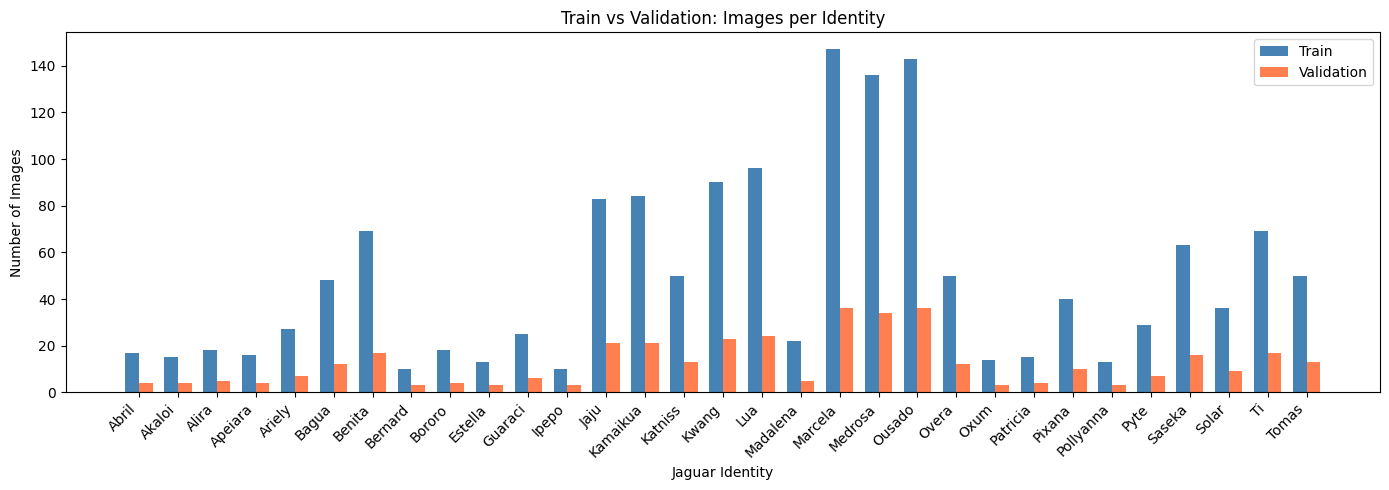


Logged identity distributions to W&B
  Train samples per identity: 10 - 147 (mean: 48.9)
  Val samples per identity: 3 - 36 (mean: 12.2)


In [6]:
# Create stratified train/validation split
# This ensures all identities appear in both sets

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split: each identity's images are split proportionally
train_data, val_data = train_test_split(
    train_df,
    test_size=shared_config["val_split"],
    random_state=shared_config["seed"],
    stratify=train_df['ground_truth']  # Ensures proportional representation
)

print(f"Dataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-shared_config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*shared_config['val_split']:.0f}%)")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())

print(f"\nIdentity coverage:")
print(f"  Identities in training:   {len(train_identities)}")
print(f"  Identities in validation: {len(val_identities)}")
print(f"  Overlap: {len(train_identities & val_identities)}")

if train_identities == val_identities:
    print("  All identities present in both sets")

# Log identity distributions to W&B
train_counts = train_data['ground_truth'].value_counts().sort_index()
val_counts = val_data['ground_truth'].value_counts().sort_index()

# Create a comparison table for W&B
distribution_df = pd.DataFrame({
    'identity': train_counts.index,
    'train_count': train_counts.values,
    'val_count': val_counts.values,
    'total_count': train_counts.values + val_counts.values,
    'train_ratio': train_counts.values / (train_counts.values + val_counts.values)
})

# Log table and summary stats to W&B
wandb.log({
    "identity_distribution_table": wandb.Table(dataframe=distribution_df),
    "num_identities": num_classes,
    "train_samples": len(train_data),
    "val_samples": len(val_data),
    "train_samples_per_identity": wandb.Histogram(train_counts.values),
    "val_samples_per_identity": wandb.Histogram(val_counts.values),
})

# Visualize train vs val distribution
fig, ax = plt.subplots(figsize=(14, 5))
width = 0.35
x = np.arange(len(train_counts))
ax.bar(x - width/2, train_counts.values, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_counts.values, width, label='Validation', color='coral')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Train vs Validation: Images per Identity')
ax.set_xticks(x)
ax.set_xticklabels(train_counts.index, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
wandb.log({"train_val_distribution": wandb.Image(fig)})
plt.show()

print(f"\nLogged identity distributions to W&B")
print(f"  Train samples per identity: {train_counts.min()} - {train_counts.max()} (mean: {train_counts.mean():.1f})")
print(f"  Val samples per identity: {val_counts.min()} - {val_counts.max()} (mean: {val_counts.mean():.1f})")

## Training Utils

In [7]:
device = get_device()
print(f"Using device: {device}")

num_workers = min(8, os.cpu_count())
print(f"Using num_workers={num_workers} for DataLoader")

Using CUDA GPU
Using device: cuda
Using num_workers=8 for DataLoader


In [8]:
filenames = train_df.index.astype(str)
train_mask = filenames.isin(train_data.index.astype(str))

filenames = filenames.to_numpy()
labels = train_df["label_encoded"].to_numpy()
image_paths = np.array([DATA_PATH / "train" / fn for fn in filenames])

train_labels = train_data.loc[filenames[train_mask], "label_encoded"].values
val_labels = val_data.loc[filenames[~train_mask], "label_encoded"].values

In [9]:
# Load Dino model
print("Loading Dino model...")
dino = timm.create_model(
    shared_config["dinov3_model"],
    pretrained=True
)
dino.eval()
dino.to(device)
dino.compile()

dino_config = resolve_data_config({}, model=dino)
dino_preprocess = create_transform(**dino_config, is_training=False)

dino_num_params = sum(p.numel() for p in dino.parameters())

print(f"Model loaded successfully")
print(f"  Parameters: {dino_num_params:,}")
print(f"  Preprocessing: {dino_config}")

# Get the embedding dimension from the model
with torch.no_grad():
    input_size = dino_config["input_size"]
    dummy_input = torch.randn(1, input_size[0], input_size[1], input_size[2]).to(device)
    dummy_output = dino(dummy_input)
    dino_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {dino_dim}")
    
wandb.log({
    "dino_num_params": dino_num_params,
    "dino_embedding_dim": dino_dim,
    "dino_input_size": dino_config["input_size"],
    "dino_preprocessing": str(dino_config),
})

Loading Dino model...


Model loaded successfully
  Parameters: 85,641,216
  Preprocessing: {'input_size': [3, 256, 256], 'interpolation': 'bicubic', 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225], 'crop_pct': 1.0, 'crop_mode': 'center'}
  Embedding dimension: 768


We use the augmentations from the [Class Balance Notebook](07_class_balance.ipynb) to generate additional samples for underrepresented identities.

In [10]:
augment = transforms.Compose([
    # Randomly flip images horizontally; mimic different side of jaguar
    transforms.RandomHorizontalFlip(),

    # Crop and resize randomly to simulate different distances and framing
    transforms.RandomResizedCrop(dino_dim, scale=(0.85, 1.0)),

    # Small rotations to account for camera angle variation without distorting fur patterns
    transforms.RandomRotation(15),

    # Slight affine transformation: translation and scaling to simulate animal movement
    transforms.RandomAffine(
        degrees=0,           # no extra rotation
        translate=(0.05, 0.05),
        scale=(0.9, 1.1)
    ),

    # Subtle color changes to mimic lighting variation; avoid distorting natural fur
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.05
    ),

    # Apply slight blur to simulate motion blur or out-of-focus shots
    transforms.GaussianBlur(5, sigma=(0.1, 1.0)),
])

In [11]:
augment_dir = OUTPUT_PATH / "augmented_data"
os.makedirs(augment_dir, exist_ok=True)

train_image_paths = np.array(image_paths)[train_mask]

augmented_paths = []
augmented_labels = []

min_images_per_identity = shared_config["min_images_per_identity"]

for label in tqdm(range(num_classes), desc="Augmenting classes"):

    mask = train_labels == label
    label_paths = train_image_paths[mask]
    needed = max(0, min_images_per_identity - len(label_paths))

    print(f"Class {label}: {len(label_paths)} samples, need {needed} more")

    for i in range(needed):

        img_path = random.choice(label_paths)
        filename = img_path.stem
        
        # Use filename to hinder data leakage from previous runs on validation set
        save_path = augment_dir / f"class{label}_aug_{filename}.png"

        # # To save computation, we only compute images once.
        # if not save_path.exists():
        img = Image.open(img_path).convert("RGBA")
        aug_img = augment(img)
        aug_img.save(save_path)

        augmented_paths.append(save_path)
        augmented_labels.append(label)

augmented_paths = np.array(augmented_paths)
augmented_labels = np.array(augmented_labels)

combined_train_paths = np.concatenate([train_image_paths, augmented_paths])
combined_train_labels = np.concatenate([train_labels, augmented_labels])

combined_train_filenames = np.array([p.name for p in combined_train_paths])

Augmenting classes:   0%|          | 0/31 [00:00<?, ?it/s]

Class 0: 17 samples, need 33 more


Augmenting classes:   3%|▎         | 1/31 [00:10<05:17, 10.58s/it]

Class 1: 15 samples, need 35 more


Augmenting classes:   6%|▋         | 2/31 [00:19<04:46,  9.89s/it]

...

Class 26: 29 samples, need 21 more


Augmenting classes:  87%|████████▋ | 27/31 [02:54<00:26,  6.68s/it]

Class 27: 63 samples, need 0 more
Class 28: 36 samples, need 14 more


Augmenting classes: 100%|██████████| 31/31 [02:59<00:00,  5.80s/it]

Class 29: 69 samples, need 0 more
Class 30: 50 samples, need 0 more


In [12]:
val_paths = np.array(image_paths)[~train_mask]
val_filenames = np.array([p.name for p in val_paths])

all_paths = np.concatenate([combined_train_paths, val_paths])
all_filenames = np.concatenate([combined_train_filenames, val_filenames])

all_labels = np.concatenate([combined_train_labels, val_labels])

image_dataset = BlurImageDataset(
    all_paths,
    preprocess_fn=dino_preprocess
)
image_loader = DataLoader(
    image_dataset,
    batch_size=32,
    num_workers=num_workers,
    shuffle=False,
    pin_memory=True,
)

print(f"Image DataLoader created with {len(image_loader)} batches")

Image DataLoader created with 76 batches


In [13]:
baseline_cache_path = OUTPUT_PATH / "dino_blur_embeddings_augmented.npz"

baseline_embeddings = get_embeddings(
    model=dino,
    cache_path=baseline_cache_path,
    data_loader=image_loader,
    filenames=all_filenames,
    device=device
)

Extracting embeddings for 76 images...


Extracting embeddings:   0%|          | 0/76 [00:00<?, ?it/s]

Extracting embeddings: 100%|██████████| 76/76 [05:34<00:00,  4.40s/it]


Saved embeddings cache to /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/08b_hyperparameter_sweep/dino_blur_embeddings_augmented.npz
Embeddings shape: (2409, 768)


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


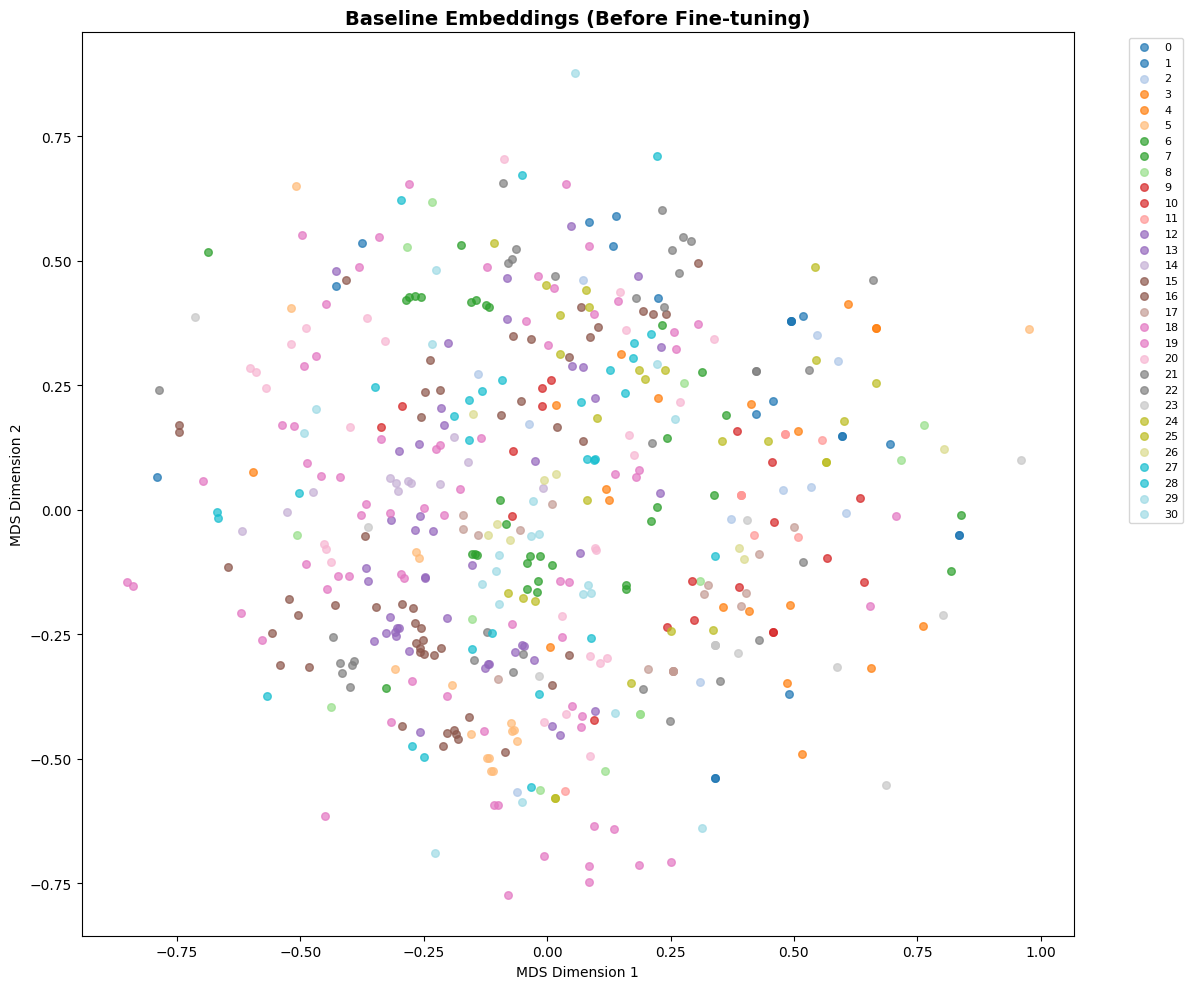

In [14]:
# Visualize DINO embeddings
fig = visualize_embeddings_mds(
    baseline_embeddings,
    all_labels,
    "Baseline Embeddings (Before Fine-tuning)",
    seed=shared_config['seed']
)
plt.savefig(OUTPUT_PATH / "baseline_embeddings_mds.png")
plt.show()

# Log to W&B
wandb.log({"baseline_embeddings_mds": wandb.Image(fig)})

In [15]:
# Train Dataset contains real and augmented images
baseline_emb_train_dataset = EmbeddingDataset(
    baseline_embeddings[:len(combined_train_paths)],
    combined_train_labels
)

baseline_emb_val_dataset = EmbeddingDataset(
    baseline_embeddings[len(combined_train_paths):],
    val_labels
)

In [ ]:
def create_training_components(config, device):
    model = EmbeddingProjection(
        input_dim=dino_dim,
        output_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"]
    ).to(device)
    
    model.print_model_summary()
    
    wandb.log({"num_projection_params": sum(p.numel() for p in model.parameters())})
    
    criterion = CombinedLoss(
        first_loss=CenterLoss(
            num_classes=num_classes, 
            embedding_dim=config["embedding_dim"]
        ),
        second_loss=ProxyAnchorLoss(
            num_classes=num_classes, 
            embedding_dim=config["embedding_dim"], 
            margin=config["proxyanchor_margin"], 
            alpha=config["proxyanchor_alpha"]
        ),
        lambda_center=config["proxyanchor_lambda"]
    ).to(device)
    
    print(f"Combined Loss: CenterLoss + ProxyAnchor")
    print(f"  ProxyAnchor margin: {config['proxyanchor_margin']}")
    print(f"  ProxyAnchor alpha: {config['proxyanchor_alpha']}")
    print(f"  Lambda: {config['proxyanchor_lambda']}")
    
    train_loader = create_deterministic_training_dataloader(
        baseline_emb_train_dataset,
        batch_size=config["batch_size"],
        seed=shared_config['seed'],
        num_workers=num_workers,
        
    )
    val_loader = DataLoader(
        baseline_emb_val_dataset,
        batch_size=config["batch_size"],
        num_workers=num_workers,
        shuffle=False
    )
    
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(criterion.parameters()),
        lr=config["init_learning_rate"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config["max_learning_rate"],
        epochs=config["num_epochs"],
        steps_per_epoch=len(train_loader),
        pct_start=config["pct_start"],
        anneal_strategy='cos',
        cycle_momentum=False,
    )
    
    print("Training components initialized:")
    print(f"  Optimizer: AdamW (lr={config['init_learning_rate']}, weight_decay={config['weight_decay']})")
    print(f"  Scheduler: OneCycleLR (max_lr={config['max_learning_rate']}, epochs={config['num_epochs']}, steps_per_epoch={len(train_loader)})")

    return model, criterion, optimizer, scheduler, train_loader, val_loader

We consolidate all comparison plots and metrics into a single function for easier evaluation and analysis.


In [ ]:
random_idx = np.random.randint(0, len(val_labels))

def train(config, device, name):
    # Setup training components
    (
        model,
        criterion,
        optimizer,
        scheduler,
        train_loader,
        val_loader
    ) = create_training_components(config, device)
    
    # Training loop
    set_seeds(shared_config['seed'])
    checkpoint_path = CHECKPOINT_PATH / f"best_model_{name}.pth"
    start_time = time.time()
    history, best_map, best_epoch = train_loop(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        scheduler, 
        device,
        name=name,
        checkpoint_path=checkpoint_path,
        num_epochs=shared_config["num_epochs"],
        patience=shared_config["patience"],
        classes=label_encoder.classes_.tolist()
    )
    training_time = time.time() - start_time

    wandb.log({
        f"final_val_mAP_{name}": best_map,
        f"best_epoch_{name}": best_epoch,
        f"total_epochs_{name}": len(history['train_loss']),
        f"training_time_{name}": training_time
    })
    
    print(f"Training completed for {name}")
    print(f"  Best val mAP: {best_map:.4f} at epoch {best_epoch}")
    print(f"  Total training time: {training_time:.2f} seconds")
    
    
    # Plot training curves
    fig = plot_history(history, best_epoch)
    plt.savefig(CHECKPOINT_PATH / f'training_curves_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Log to W&B
    wandb.log({f"training_curves_{name}": wandb.Image(fig)})
    
    
    # Load best model
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Loaded best model from epoch {best_epoch}")
    print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
    print(f"  Val mAP: {checkpoint['val_map']:.4f}")
    
    
    # Extract fine-tuned embeddings for training data
    model.eval()
    with torch.no_grad():
        train_tensor = torch.FloatTensor(baseline_embeddings).to(device)
        finetuned_embeddings = model(train_tensor).cpu().numpy()
        finetuned_embeddings = finetuned_embeddings / np.linalg.norm(finetuned_embeddings, axis=1, keepdims=True)

    print(f"Fine-tuned embeddings shape: {finetuned_embeddings.shape}")
    print(f"Mean L2 norm: {np.linalg.norm(finetuned_embeddings, axis=1).mean():.4f}")
    
    
    # Visualize fine-tuned embeddings
    fig_finetuned = visualize_embeddings_mds(
        finetuned_embeddings,
        all_labels,
        f"Fine-tuned Embeddings (After Training, {name})",
        seed=shared_config['seed']
    )
    plt.savefig(OUTPUT_PATH / f"embeddings_mds_{name}.png")
    plt.show()

    # Log to W&B
    wandb.log({f"embeddings_mds_{name}": wandb.Image(fig_finetuned)})
    
    
    # Visualize nearest neighbors before and after fine-tuning
    fig, stats = visualize_nearest_neighbors(
        query_idx=random_idx,
        original_embeddings=baseline_embeddings[len(combined_train_paths):],
        finetuned_embeddings=finetuned_embeddings[len(combined_train_paths):],
        image_paths=all_paths[len(combined_train_paths):],
        labels=val_labels,
        before_label='BEFORE\nFine-Tuning\n(DINOv3)',
        after_label='AFTER\nFine-Tuning\n(Center + Proxy Anchor)'
    )

    fig.savefig(OUTPUT_PATH / f"nearest_neighbors_{name}.png", dpi=150, bbox_inches='tight')
    fig.show()

    wandb.log({
        f"nearest_neighbors_{name}": wandb.Image(fig),
        f"nearest_neighbors_stats_{name}": stats,
    })
    
    return [
        name,
        best_map,
        best_epoch,
        training_time
    ]


In [18]:
table = [
    ["Run ID", "Best val_mAP", "Best epoch", "Training time"]
]

## Baseline

For the baseline, we use the hyperparameters that were optimized in previous notebooks.


In [19]:
# Baselin Configuration
baseline_config = {       
    # Model
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    
    # ProxyAnchor
    "proxyanchor_margin": 0.1,
    "proxyanchor_alpha": 32.0,
    "proxyanchor_lambda": 0.0005,
    
    # AdamW
    "init_learning_rate": 5e-5,
    "weight_decay": 1e-4,
    
    # OneCycleLR
    "max_learning_rate": 1e-3,
    "pct_start": 0.3,

    # Training
    "batch_size": 32,
    "weight_decay": 1e-4,
} | shared_config

print("Configuration:")
for key, value in baseline_config.items():
    print(f"  {key}: {value}")

Configuration:
  embedding_dim: 256
  hidden_dim: 512
  dropout: 0.3
  proxyanchor_margin: 0.1
  proxyanchor_alpha: 32.0
  proxyanchor_lambda: 0.0005
  init_learning_rate: 5e-05
  weight_decay: 0.0001
  max_learning_rate: 0.001
  pct_start: 0.3
  batch_size: 32
  sweep_id: jeuoccta
  num_top_runs: 3
  dinov3_model: hf-hub:timm/vit_base_patch16_dinov3.lvd1689m
  num_epochs: 200
  patience: 10
  val_split: 0.2
  min_images_per_identity: 50
  seed: 4


Embedding Projection:
  Input dim: 768
  Hidden dim: 512
  Output dim: 256
  Dropout: 0.3
  Total parameters: 526592
Combined Loss: CenterLoss + ProxyAnchor
  ProxyAnchor margin: 0.1
  ProxyAnchor alpha: 32.0
  Lambda: 0.0005
Training components initialized:
  Optimizer: AdamW (lr=5e-05, weight_decay=0.0001)
  Scheduler: OneCycleLR (max_lr=0.001, epochs=200, steps_per_epoch=64)
All random seeds set to 4 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/64 [00:00<?, ?it/s]

  Train Loss: 496.5648
  Val Loss:   375.3614
  Val mAP:    0.3790 | LR: 4.07e-05
  [New best model saved]

Epoch 2/200


  Train Loss: 471.9709
  Val Loss:   355.4169
  Val mAP:    0.3822 | LR: 4.26e-05
  [New best model saved]

Epoch 3/200


  Train Loss: 448.0229
  Val Loss:   331.2850
  Val mAP:    0.3893 | LR: 4.59e-05
  [New best model saved]

Epoch 4/200


...

  Train Loss: 11.1032
  Val Loss:   11.2110
  Val mAP:    0.8936 | LR: 9.82e-04
  No improvement. Patience: 6/10

Epoch 73/200


  Train Loss: 10.6855
  Val Loss:   10.7874
  Val mAP:    0.8909 | LR: 9.79e-04
  No improvement. Patience: 7/10

Epoch 74/200


  Train Loss: 10.0266
  Val Loss:   10.4943
  Val mAP:    0.8867 | LR: 9.75e-04
  No improvement. Patience: 8/10

Epoch 75/200


  Train Loss: 9.5286
  Val Loss:   10.2770
  Val mAP:    0.8952 | LR: 9.72e-04
  No improvement. Patience: 9/10

Epoch 76/200


  Train Loss: 9.6135
  Val Loss:   10.0053
  Val mAP:    0.8913 | LR: 9.68e-04
  No improvement. Patience: 10/10

Early stopping triggered after 76 epochs

Training complete!
Best epoch: 66, Val mAP: 0.8990
Training completed for baseline
  Best val mAP: 0.8990 at epoch 66
  Total training time: 114.02 seconds


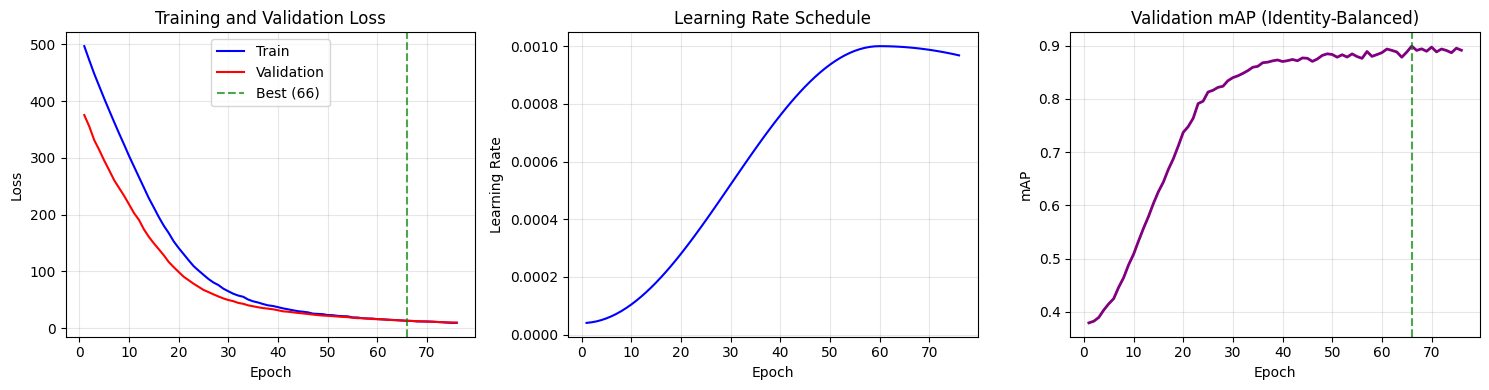

Loaded best model from epoch 66
  Val Loss: 13.2735
  Val mAP: 0.8990
Fine-tuned embeddings shape: (2409, 256)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


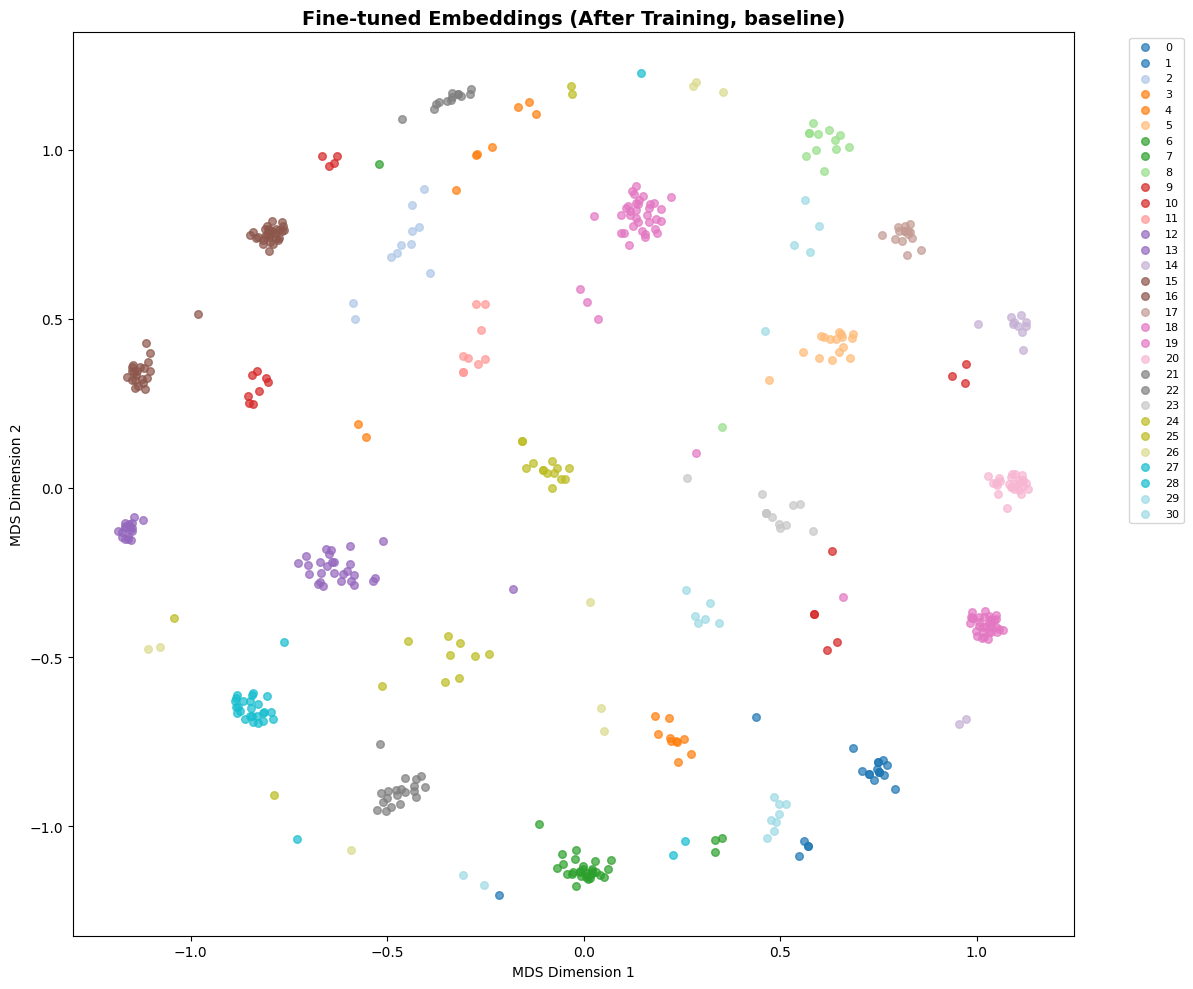

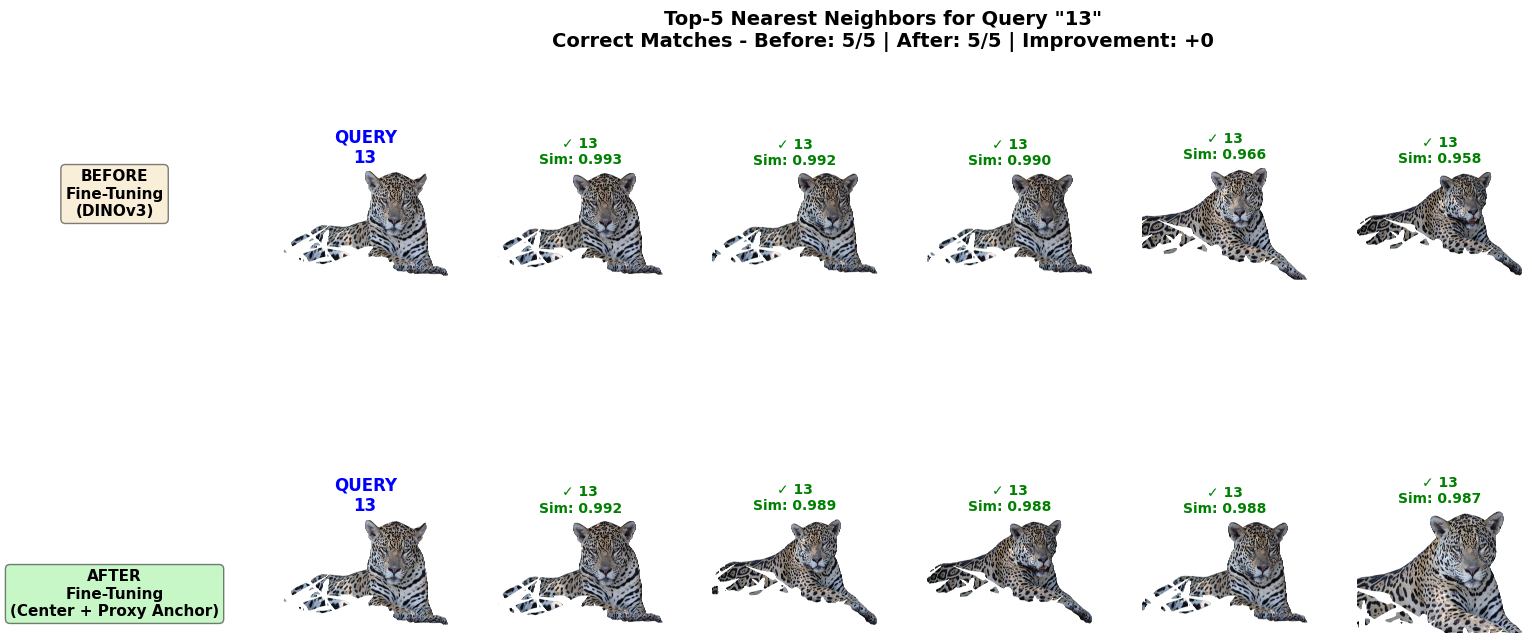

In [20]:
baseline_table_row = train(baseline_config, device, name="baseline")
table.append(baseline_table_row)

## Best Sweep Runs

In [21]:
api = wandb.Api()
entity = api.viewer.entity  # gets your W&B username
sweep_path = f"{entity}/{os.getenv('WANDB_PROJECT')}/{shared_config['sweep_id']}"
print(f"Sweep results available at: https://wandb.ai/{sweep_path}")

Sweep results available at: https://wandb.ai/karl-schuetz-hasso-plattner-institut/jaguar-reid-karl-matti-schuetz/jeuoccta


In [22]:
# Access the sweep via W&B API
api = wandb.Api()
sweep = api.sweep(sweep_path)

# Sort runs by your metric (final_val_mAP) descending
sorted_runs = sorted(
    sweep.runs, 
    key=lambda run: run.summary.get("final_val_mAP", float('-inf')),
    reverse=True
)

# Show the top runs
print(f"Top {shared_config['num_top_runs']} runs:")
for i, run in enumerate(sorted_runs[:shared_config["num_top_runs"]], 1):
    print(f"\nRank {i}:")
    print("Run ID:", run.id)
    print("final_val_mAP:", run.summary.get("final_val_mAP"))
    print("Hyperparameters:", run.config)

Top 3 runs:

Rank 1:
Run ID: ferxn83y
final_val_mAP: 0.8893143931454007
Hyperparameters: {'seed': 66, 'dropout': 0.1, 'patience': 10, 'pct_start': 0.4, 'val_split': 0.2, 'batch_size': 32, 'hidden_dim': 1024, 'num_epochs': 200, 'dinov3_model': 'hf-hub:timm/vit_base_patch16_dinov3.lvd1689m', 'max_num_runs': 100, 'weight_decay': 5.5851846958342855e-06, 'embedding_dim': 512, 'max_learning_rate': 0.0036559990748962086, 'proxyanchor_alpha': 64, 'init_learning_rate': 0.0001219091351055742, 'proxyanchor_lambda': 2.747379652091493e-05, 'proxyanchor_margin': 0.3, 'min_images_per_identity': 50}

Rank 2:
Run ID: nnoo062x
final_val_mAP: 0.8888649856536639
Hyperparameters: {'seed': 66, 'dropout': 0.1, 'patience': 10, 'pct_start': 0.2, 'val_split': 0.2, 'batch_size': 32, 'hidden_dim': 768, 'num_epochs': 200, 'dinov3_model': 'hf-hub:timm/vit_base_patch16_dinov3.lvd1689m', 'max_num_runs': 100, 'weight_decay': 6.558947661838139e-06, 'embedding_dim': 512, 'max_learning_rate': 0.007514589946885167, 'proxy

In [23]:
candidate_runs = sorted_runs[:shared_config["num_top_runs"]]  # You can adjust this number based on how many top runs you want to analyze


Analyzing run ferxn83y
Embedding Projection:
  Input dim: 768
  Hidden dim: 1024
  Output dim: 512
  Dropout: 0.1
  Total parameters: 1315328
Combined Loss: CenterLoss + ProxyAnchor
  ProxyAnchor margin: 0.3
  ProxyAnchor alpha: 64
  Lambda: 2.747379652091493e-05
Training components initialized:
  Optimizer: AdamW (lr=0.0001219091351055742, weight_decay=5.5851846958342855e-06)
  Scheduler: OneCycleLR (max_lr=0.0036559990748962086, epochs=200, steps_per_epoch=64)
All random seeds set to 4 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


Training:   0%|          | 0/64 [00:00<?, ?it/s]

  Train Loss: 871.8356
  Val Loss:   661.1792
  Val mAP:    0.4332 | LR: 1.48e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 660.5937
  Val Loss:   527.6975
  Val mAP:    0.5047 | LR: 1.52e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 536.6650
  Val Loss:   433.4451
  Val mAP:    0.5673 | LR: 1.58e-04
  [New best model saved]

Epoch 4/200


...

  Train Loss: 21.8326
  Val Loss:   32.4653
  Val mAP:    0.8981 | LR: 2.24e-03
  No improvement. Patience: 6/10

Epoch 46/200


  Train Loss: 19.7897
  Val Loss:   31.2854
  Val mAP:    0.8953 | LR: 2.31e-03
  No improvement. Patience: 7/10

Epoch 47/200


  Train Loss: 18.9574
  Val Loss:   29.9371
  Val mAP:    0.8944 | LR: 2.38e-03
  No improvement. Patience: 8/10

Epoch 48/200


  Train Loss: 18.2814
  Val Loss:   28.5279
  Val mAP:    0.8965 | LR: 2.44e-03
  No improvement. Patience: 9/10

Epoch 49/200


  Train Loss: 18.1133
  Val Loss:   26.5157
  Val mAP:    0.8997 | LR: 2.51e-03
  No improvement. Patience: 10/10

Early stopping triggered after 49 epochs

Training complete!
Best epoch: 39, Val mAP: 0.9022
Training completed for ferxn83y
  Best val mAP: 0.9022 at epoch 39
  Total training time: 75.96 seconds


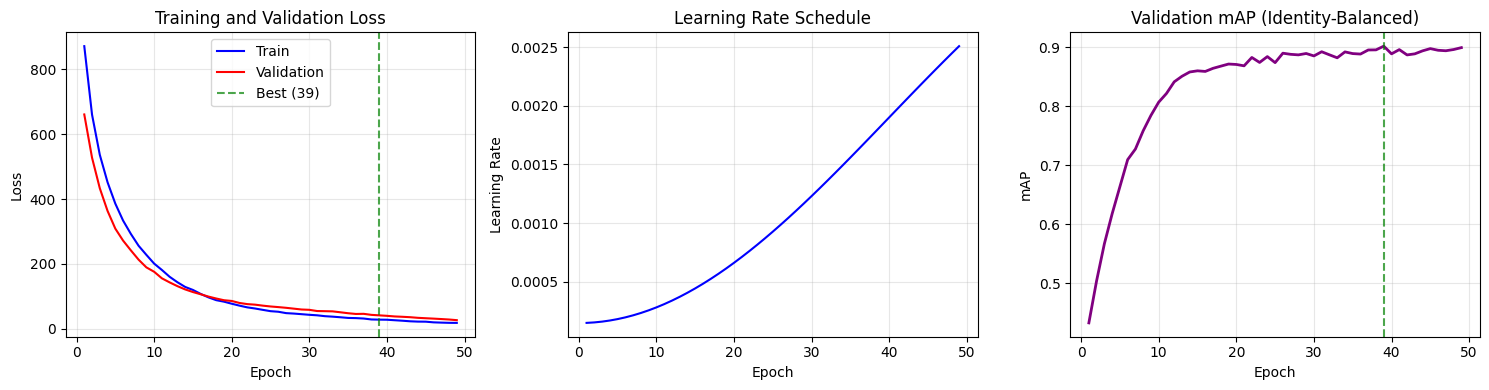

Loaded best model from epoch 39
  Val Loss: 41.3755
  Val mAP: 0.9022
Fine-tuned embeddings shape: (2409, 512)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


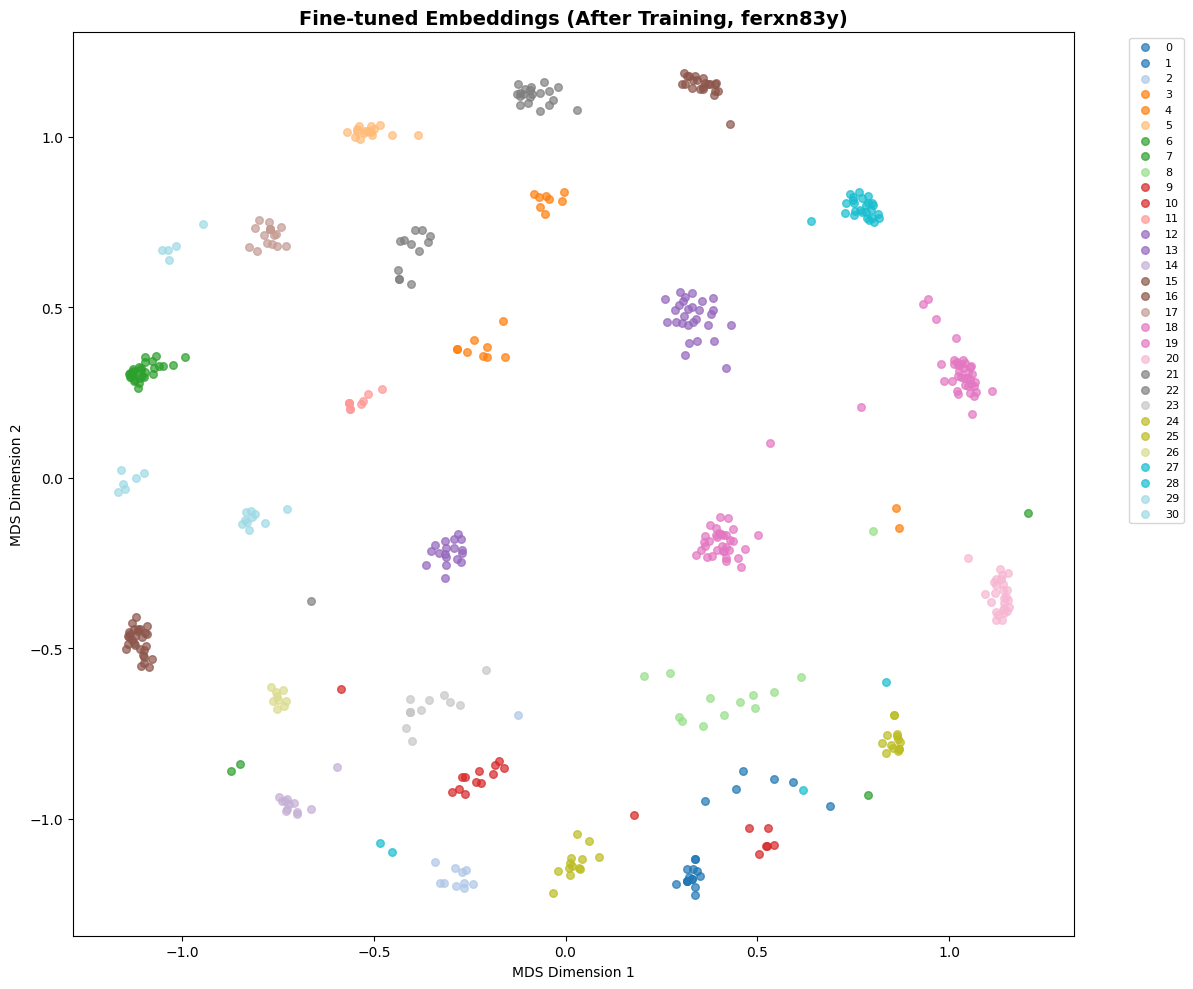


Analyzing run nnoo062x
Embedding Projection:
  Input dim: 768
  Hidden dim: 768
  Output dim: 512
  Dropout: 0.1
  Total parameters: 986880
Combined Loss: CenterLoss + ProxyAnchor
  ProxyAnchor margin: 0.2
  ProxyAnchor alpha: 16
  Lambda: 1.139770561131301e-05
Training components initialized:
  Optimizer: AdamW (lr=5.4031393553434475e-05, weight_decay=6.558947661838139e-06)
  Scheduler: OneCycleLR (max_lr=0.007514589946885167, epochs=200, steps_per_epoch=64)
All random seeds set to 4 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 810.8025
  Val Loss:   585.8839
  Val mAP:    0.4566 | LR: 3.12e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 551.5540
  Val Loss:   419.5891
  Val mAP:    0.5706 | LR: 3.45e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 408.6426
  Val Loss:   314.8368
  Val mAP:    0.6555 | LR: 4.00e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 313.8710
  Val Loss:   247.7632
  Val mAP:    0.7160 | LR: 4.77e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 5.9956
  Val Loss:   8.1229
  Val mAP:    0.9044 | LR: 7.24e-03
  No improvement. Patience: 6/10

Epoch 36/200


  Train Loss: 5.4644
  Val Loss:   7.2361
  Val mAP:    0.9046 | LR: 7.34e-03
  No improvement. Patience: 7/10

Epoch 37/200


  Train Loss: 4.7957
  Val Loss:   6.4431
  Val mAP:    0.9007 | LR: 7.42e-03
  No improvement. Patience: 8/10

Epoch 38/200


  Train Loss: 4.0111
  Val Loss:   5.5707
  Val mAP:    0.9015 | LR: 7.47e-03
  No improvement. Patience: 9/10

Epoch 39/200


  Train Loss: 3.5581
  Val Loss:   4.8343
  Val mAP:    0.9013 | LR: 7.50e-03
  No improvement. Patience: 10/10

Early stopping triggered after 39 epochs

Training complete!
Best epoch: 29, Val mAP: 0.9080
Training completed for nnoo062x
  Best val mAP: 0.9080 at epoch 29
  Total training time: 63.68 seconds


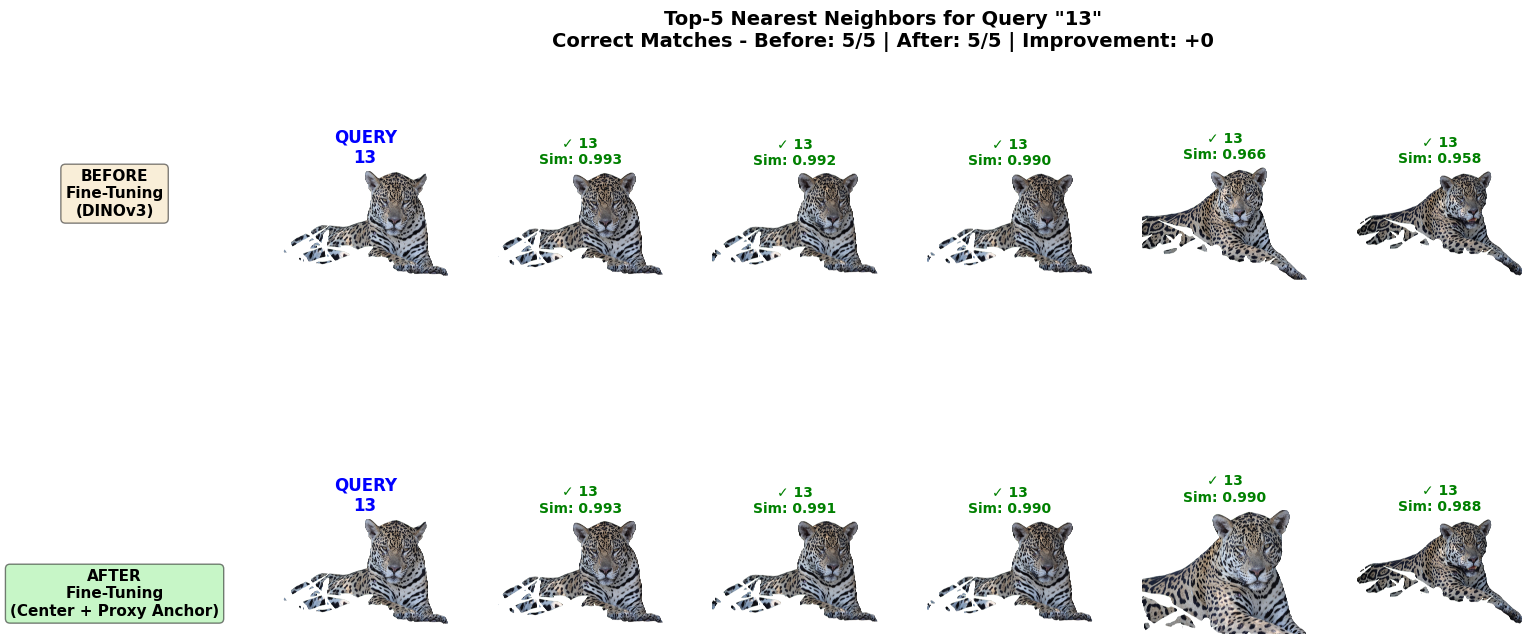

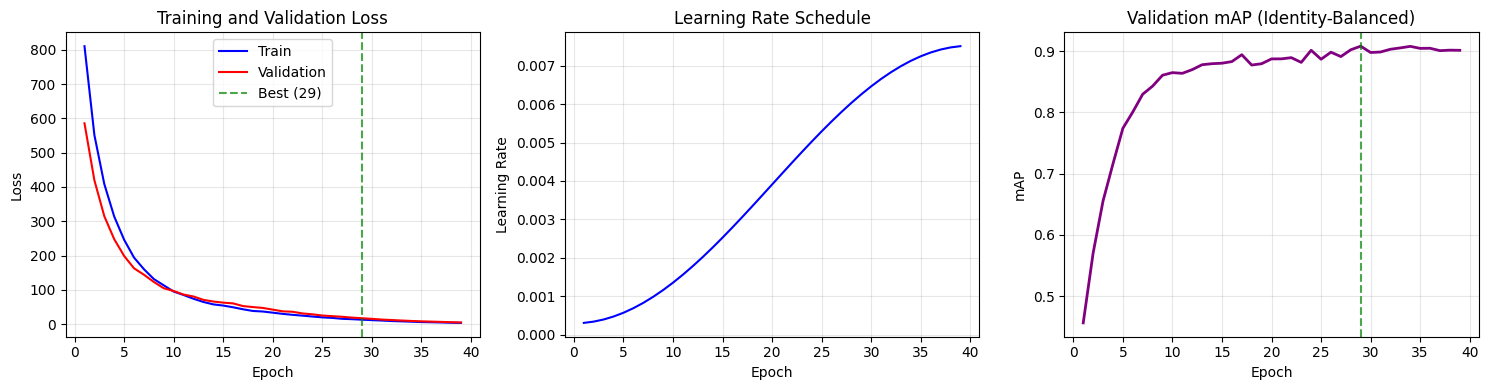

Loaded best model from epoch 29
  Val Loss: 17.1644
  Val mAP: 0.9080
Fine-tuned embeddings shape: (2409, 512)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


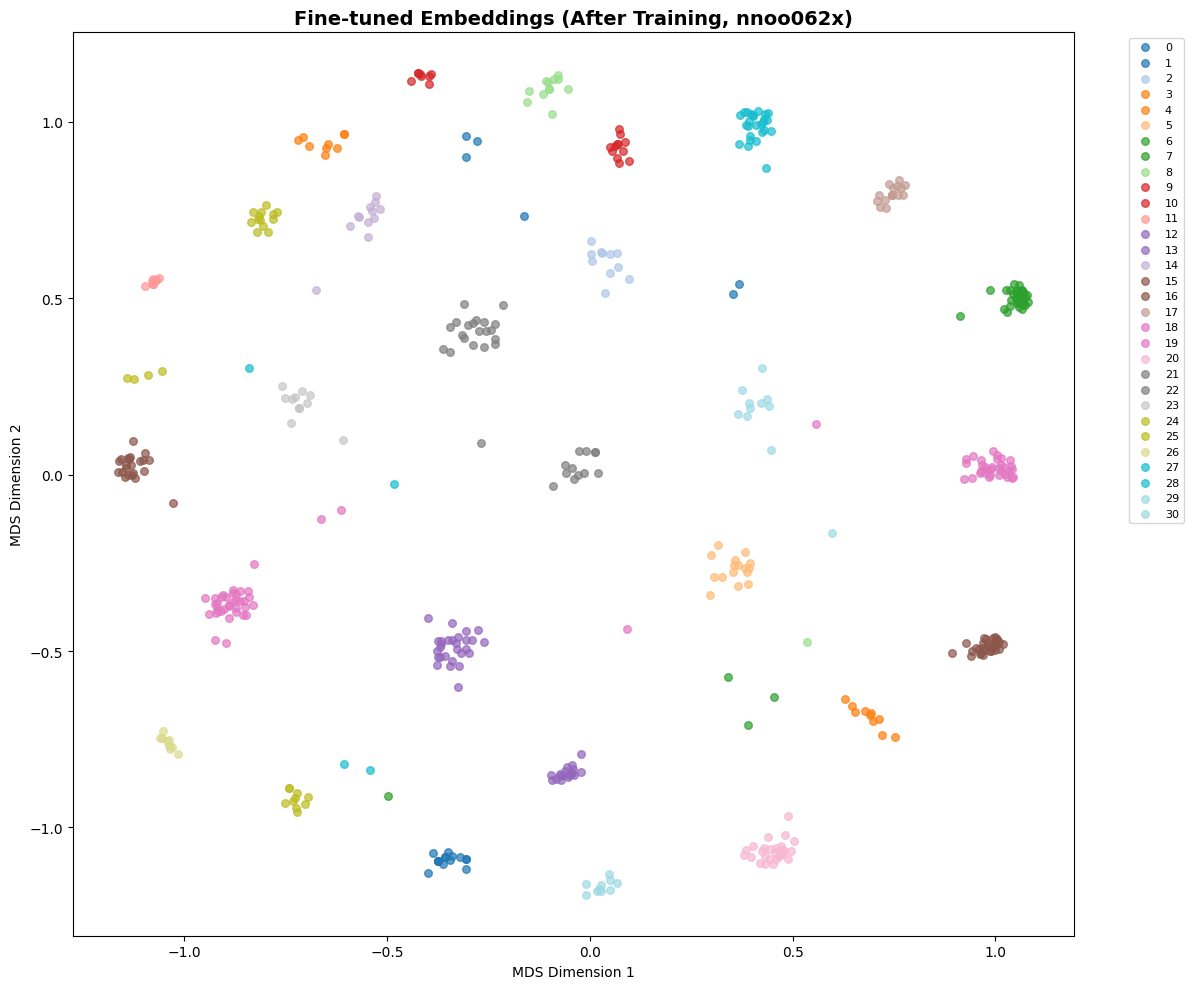


Analyzing run yzhfspuz
Embedding Projection:
  Input dim: 768
  Hidden dim: 256
  Output dim: 512
  Dropout: 0.4
  Total parameters: 329984
Combined Loss: CenterLoss + ProxyAnchor
  ProxyAnchor margin: 0.2
  ProxyAnchor alpha: 64
  Lambda: 2.926997273663864e-05
Training components initialized:
  Optimizer: AdamW (lr=0.0008186175818406476, weight_decay=0.0001303985976363136)
  Scheduler: OneCycleLR (max_lr=0.002566289385829282, epochs=200, steps_per_epoch=64)
All random seeds set to 4 for reproducibility
Starting training for 200 epochs...

Epoch 1/200


  Train Loss: 1000.3423
  Val Loss:   710.9857
  Val mAP:    0.3786 | LR: 1.18e-04
  [New best model saved]

Epoch 2/200


  Train Loss: 932.1793
  Val Loss:   643.1886
  Val mAP:    0.3911 | LR: 1.63e-04
  [New best model saved]

Epoch 3/200


  Train Loss: 848.6221
  Val Loss:   568.6470
  Val mAP:    0.4170 | LR: 2.37e-04
  [New best model saved]

Epoch 4/200


  Train Loss: 745.7014
  Val Loss:   490.4603
  Val mAP:    0.4656 | LR: 3.38e-04
  [New best model saved]

Epoch 5/200


...

  Train Loss: 10.2787
  Val Loss:   6.8453
  Val mAP:    0.8837 | LR: 2.46e-03
  No improvement. Patience: 6/10

Epoch 45/200


  Train Loss: 9.7546
  Val Loss:   6.4048
  Val mAP:    0.8892 | LR: 2.45e-03
  No improvement. Patience: 7/10

Epoch 46/200


  Train Loss: 8.7586
  Val Loss:   5.9060
  Val mAP:    0.8795 | LR: 2.44e-03
  No improvement. Patience: 8/10

Epoch 47/200


  Train Loss: 8.2007
  Val Loss:   5.4906
  Val mAP:    0.8810 | LR: 2.43e-03
  No improvement. Patience: 9/10

Epoch 48/200


  Train Loss: 7.6426
  Val Loss:   5.1093
  Val mAP:    0.8876 | LR: 2.42e-03
  No improvement. Patience: 10/10

Early stopping triggered after 48 epochs

Training complete!
Best epoch: 38, Val mAP: 0.8946
Training completed for yzhfspuz
  Best val mAP: 0.8946 at epoch 38
  Total training time: 77.55 seconds


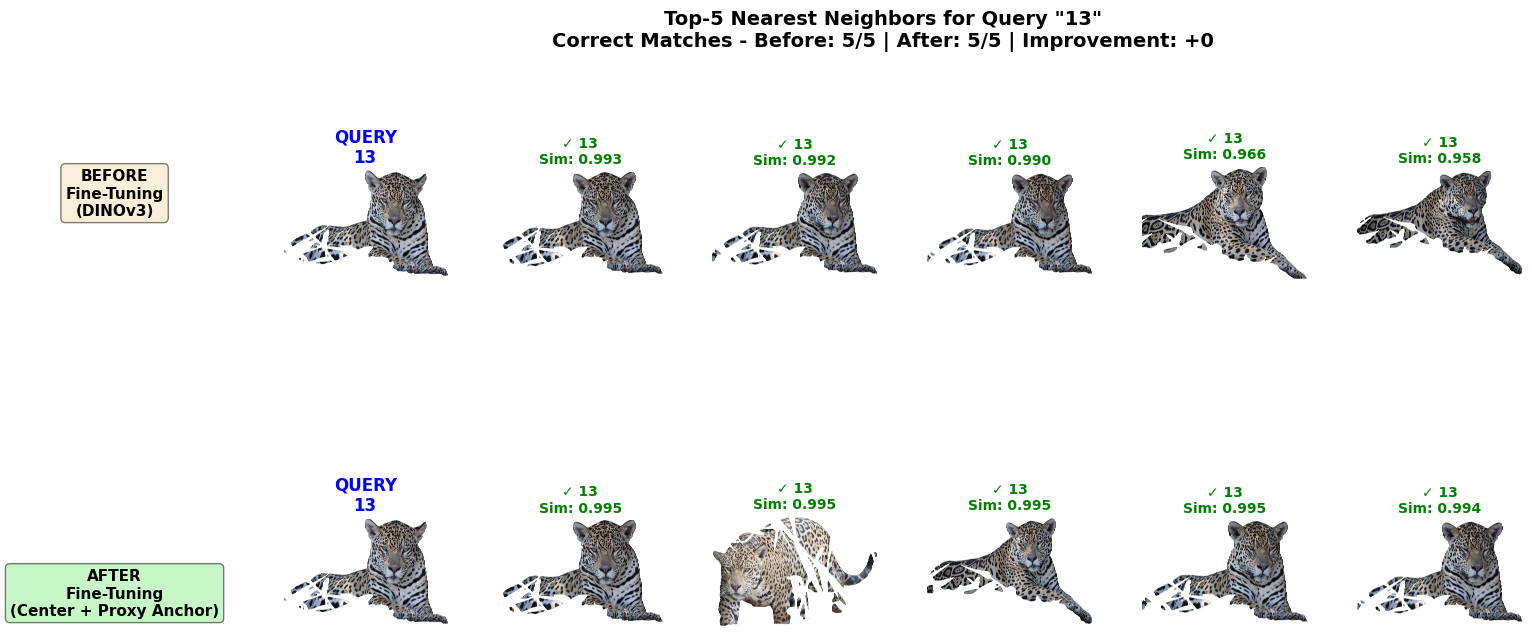

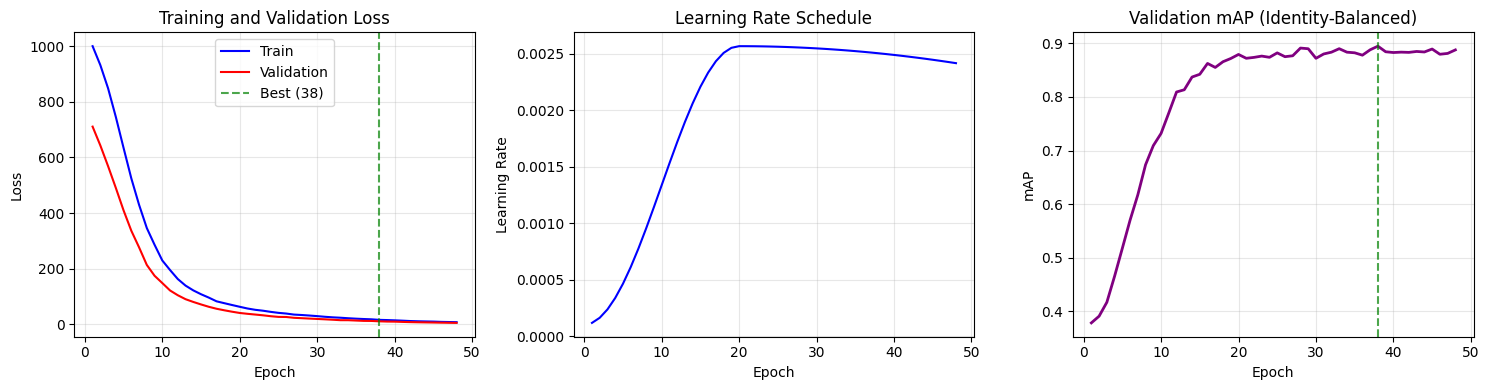

Loaded best model from epoch 38
  Val Loss: 10.7667
  Val mAP: 0.8946
Fine-tuned embeddings shape: (2409, 512)
Mean L2 norm: 1.0000


/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/.venv/lib/python3.11/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


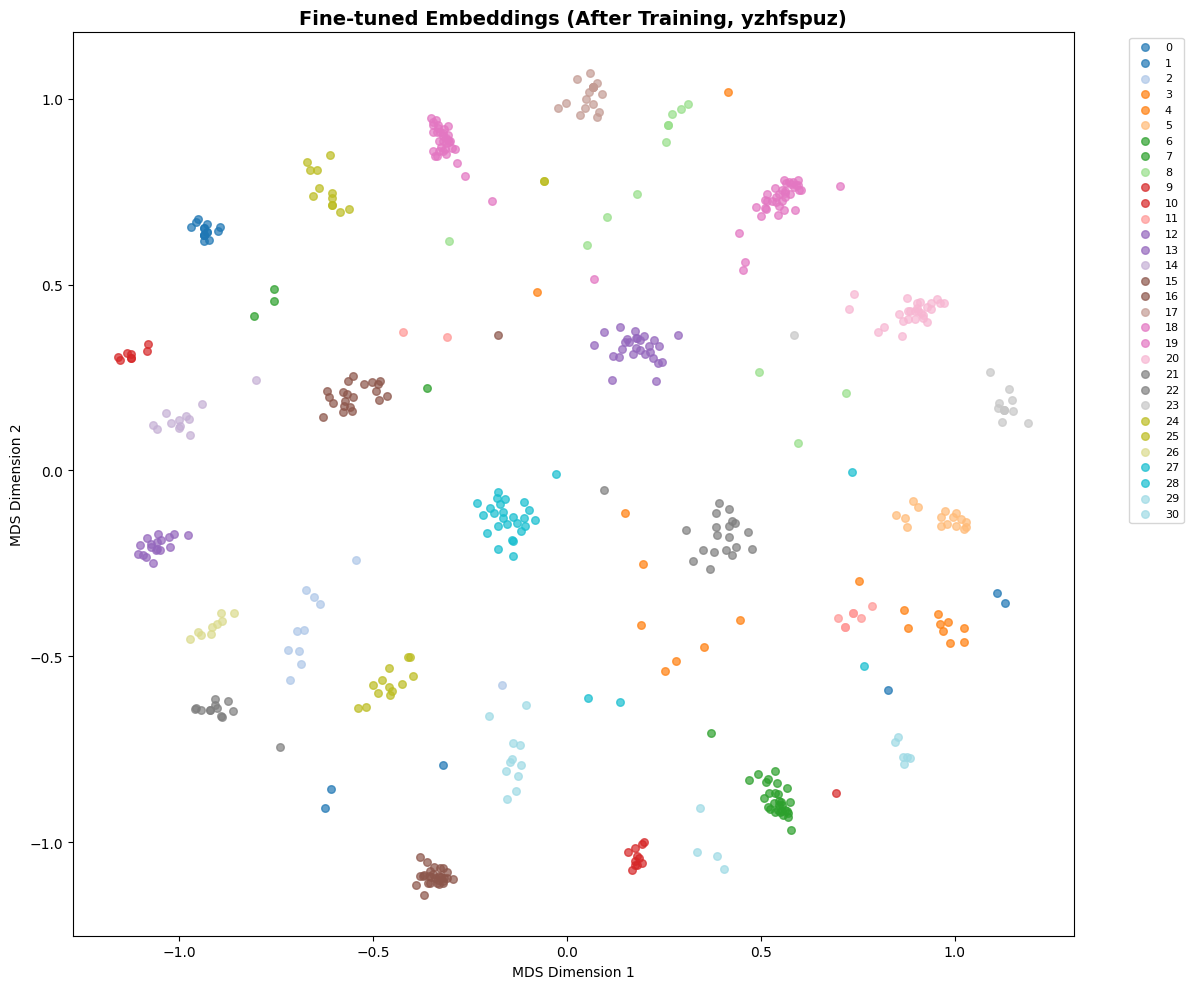

Finished analyzing top runs from the sweep


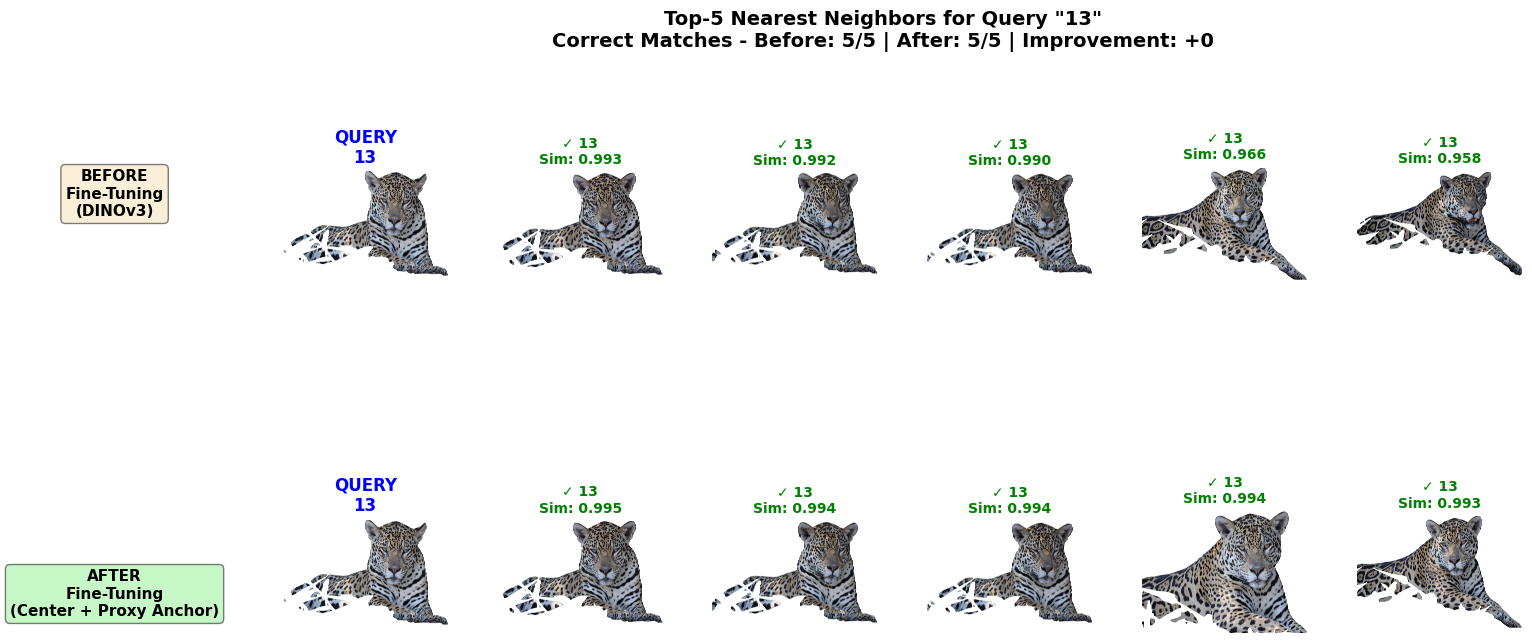

In [24]:
for run in candidate_runs:
    print(f"\nAnalyzing run {run.id}")
    row = train(run.config, device, name=run.id)
    table.append(row)

print("Finished analyzing top runs from the sweep")

## Summary

In [25]:
rows = list(zip(*table)) # transpose for tabulate
print(tabulate(rows[1:], headers=rows[0], tablefmt="grid"))

+---------------+------------+------------+------------+------------+
| Run ID        |   baseline |   ferxn83y |   nnoo062x |   yzhfspuz |
+===============+============+============+============+============+
| Best val_mAP  |   0.898983 |   0.902213 |   0.908008 |   0.894581 |
+---------------+------------+------------+------------+------------+
| Best epoch    |  66        |  39        |  29        |  38        |
+---------------+------------+------------+------------+------------+
| Training time | 114.024    |  75.9591   |  63.6847   |  77.5505   |
+---------------+------------+------------+------------+------------+


In [26]:
# create df from table and log to W&B
df = pd.DataFrame(table[1:], columns=table[0])
print(df)

wandb.log({"experiment_summary": wandb.Table(dataframe=df)})

     Run ID  Best val_mAP  Best epoch  Training time
0  baseline      0.898983          66     114.024294
1  ferxn83y      0.902213          39      75.959115
2  nnoo062x      0.908008          29      63.684694
3  yzhfspuz      0.894581          38      77.550530


Result with random seed 57:
| Run ID          | baseline | ferxn83y | nnoo062x | yzhfspuz |
|-----------------|----------|----------|----------|----------|
| Best val_mAP    | 0.837628 | **0.85543**  | 0.852157 | 0.831842 |
| Best epoch      | 75       | 59       | 31       | 34       |
| Training time   | 117.266  | 100.567  | **60.6623**  | 67.1734  |

Result with random seed 90:
| Run ID          | baseline | ferxn83y | nnoo062x | yzhfspuz |
|-----------------|----------|----------|----------|----------|
| Best val_mAP    | 0.851829 | 0.873491 | **0.878399** | 0.862811 |
| Best epoch      | 67       | 40       | 23       | 23       |
| Training time   | 115.946  | 80.5685  | **54.3101**  | 54.6302  |

Result with random seed 876:
| Run ID        | baseline | ferxn83y | nnoo062x | yzhfspuz |
|---------------|----------|----------|----------|----------|
| Best val_mAP  | **0.879425** | 0.873641 | 0.870232 | 0.855567 |
| Best epoch    | 74       | 56       | 20       | 39       |
| Training time | 123.862  | 102.636  | **48.8257**  | 79.18    |

Result with random seed 23:
| Run ID        | baseline | ferxn83y | nnoo062x | yzhfspuz |
|---------------|----------|----------|----------|----------|
| Best val_mAP  | **0.88522**  | 0.877288 | 0.87591  | 0.868977 |
| Best epoch    | 71       | 36       | 22       | 23       |
| Training time | 117.795  | 72.1934  | **52.9224**  | 54.7806  |

Result with random seed 4:
| Run ID        | baseline | ferxn83y | nnoo062x | yzhfspuz |
|---------------|----------|----------|----------|----------|
| Best val_mAP  | 0.898983 | 0.902213 | **0.908008** | 0.894581 |
| Best epoch    | 66       | 39       | 29       | 38       |
| Training time | 114.024  | 75.9591  | **63.6847**  | 77.5505  |

| Run ID   | Seed 57     | Seed 90      | Seed 876     | Seed 23     | Seed 4       | Mean mAP     | Std (mAP) | Mean Epoch | Mean Training Time | Avg Position |
| -------- | ----------- | ------------ | ------------ | ----------- | ------------ | ------------ | --------- | ---------- | ------------------ | ------------ |
| baseline | 0.837628    | 0.851829     | **0.879425** | **0.88522** | 0.898983     | 0.870217     | 0.021958  | 70.6       | 117.979            | 2.4          |
| ferxn83y | **0.85543** | 0.873491     | 0.873641     | 0.877288    | 0.902213     | 0.876413     | 0.016872  | 46.0       | 86.987             | 2.2          |
| nnoo062x | 0.852157    | **0.878399** | 0.870232     | 0.87591     | **0.908008** | **0.876541** | 0.015858  | 25.0       | **56.481**         | **1.8**      |
| yzhfspuz | 0.831842    | 0.862811     | 0.855567     | 0.868977    | 0.894581     | 0.862556     | 0.023096  | 31.4       | 66.863             | 3.0          |


## Submission

In [27]:
submission_model = candidate_runs[0].id  # Default to best run, can change to specific run ID or "baseline"

submission_dict = {
    run.id: (CHECKPOINT_PATH / f"best_model_{run.id}.pth", run.config) for run in candidate_runs
}
submission_dict["baseline"] = (CHECKPOINT_PATH / "best_model_baseline.pth", baseline_config)

if submission_model not in submission_dict:
    raise ValueError(f"Invalid submission model: {submission_model}")

checkpoint_path, config = submission_dict[submission_model]
config = config | shared_config

wandb.log({"submission_type": submission_model})

In [28]:
model = EmbeddingProjection(
    input_dim=dino_dim,
    output_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    dropout=config["dropout"]
).to(device)

In [29]:
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

EmbeddingProjection(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=1024, bias=True)
    (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [30]:
# Load test.csv to get the pairs we need to score
test_pairs_df = pd.read_csv(DATA_PATH / "test.csv")

print(f"Test pairs to score: {len(test_pairs_df)}")
print(f"Columns: {list(test_pairs_df.columns)}")
print(f"\nSample rows:")
print(test_pairs_df.head())

Test pairs to score: 137270
Columns: ['row_id', 'query_image', 'gallery_image']

Sample rows:
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png


In [31]:
# Get unique test images
test_images = set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())
test_images = sorted(list(test_images))

print(f"Unique test images: {len(test_images)}")

# Build paths
test_image_paths = [DATA_PATH / "test" / filename for filename in test_images]

test_loader = DataLoader(
    BlurImageDataset(
        test_image_paths,
        preprocess_fn=dino_preprocess
    ),
    batch_size=32,
    num_workers=num_workers,
    shuffle=False
)

# Extract embeddings for test images
print(f"\nExtracting embeddings for test images...")
test_embeddings = extract_embeddings(
    model=dino,
    data_loader=test_loader,
    device=device,
    desc="Test embeddings"
)

print(f"Test embeddings shape: {test_embeddings.shape}")

Unique test images: 371

Extracting embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test embeddings: 100%|██████████| 12/12 [01:08<00:00,  5.73s/it]

Test embeddings shape: (371, 768)


In [32]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_embeddings).to(device)
    test_finetuned_embeddings = model(test_tensor).cpu().numpy()
    test_finetuned_embeddings = test_finetuned_embeddings / np.linalg.norm(test_finetuned_embeddings, axis=1, keepdims=True)

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")
print(f"Mean L2 norm: {np.linalg.norm(test_finetuned_embeddings, axis=1).mean():.4f}")

# Create mapping from filename to embedding
img_to_embedding = {
    filename: embedding 
    for filename, embedding in zip(test_images, test_finetuned_embeddings)
}

Fine-tuned test embeddings shape: (371, 512)
Mean L2 norm: 1.0000


In [33]:
# Compute similarity for each pair
print("Computing pairwise similarities...")
similarities = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    query_emb = img_to_embedding[row['query_image']]
    gallery_emb = img_to_embedding[row['gallery_image']]
    
    # Cosine similarity (embeddings are already normalized)
    sim = np.dot(query_emb, gallery_emb)
    similarities.append(sim)

# Clip to [0, 1] range
similarities = np.array(similarities)
similarities = np.clip(similarities, 0.0, 1.0)

print(f"\nSimilarity statistics:")
print(f"  Min: {similarities.min():.4f}")
print(f"  Max: {similarities.max():.4f}")
print(f"  Mean: {similarities.mean():.4f}")
print(f"  Std: {similarities.std():.4f}")

Computing pairwise similarities...


Computing similarities: 100%|██████████| 137270/137270 [00:04<00:00, 32605.82it/s]


Similarity statistics:
  Min: 0.0000
  Max: 0.9979
  Mean: 0.1098
  Std: 0.1890


In [34]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities
})

print("Submission DataFrame:")
print(submission_df.head(10))

# Verify format matches sample submission
sample_submission = pd.read_csv(DATA_PATH / "sample_submission.csv")
print(f"\nFormat check:")
print(f"  Expected columns: {list(sample_submission.columns)}")
print(f"  Our columns: {list(submission_df.columns)}")
print(f"  Expected rows: {len(sample_submission)}")
print(f"  Our rows: {len(submission_df)}")

Submission DataFrame:
   row_id  similarity
0       0    0.472616
1       1    0.237000
2       2    0.681233
3       3    0.345464
4       4    0.319227
5       5    0.306110
6       6    0.301268
7       7    0.113477
8       8    0.255454
9       9    0.023984

Format check:
  Expected columns: ['row_id', 'similarity']
  Our columns: ['row_id', 'similarity']
  Expected rows: 137270
  Our rows: 137270


In [35]:
# Save submission
submission_path = OUTPUT_PATH / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

Submission saved to: /sc/home/karl.schuetz/hands_on_computer_vision/Kaggle-Competition-Jaguar-Re-identification/output/08b_hyperparameter_sweep/submission.csv
File size: 1965.8 KB


## Artifacts

In [36]:
# Save model as W&B artifact
for key in submission_dict:
    checkpoint_path, _ = submission_dict[key]
    model_artifact = wandb.Artifact(
        name=f"model-{key}",
        type="model",
        description="Center + ProxyAnchor fine-tuned MegaDescriptor model for jaguar re-identification with config from run: " + key
    )
    model_artifact.add_file(checkpoint_path)
    wandb.log_artifact(model_artifact)

print("Model artifacts saved to W&B")

Model artifacts saved to W&B


In [37]:
# Save submission as W&B artifact
submission_artifact = wandb.Artifact(
    name="submission",
    type="submission",
    description=f"Competition submission file for {submission_model} loss"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Submission artifact saved to W&B")

Submission artifact saved to W&B


In [38]:
wandb.finish()

best_epoch_baseline,▁
best_epoch_ferxn83y,▁
best_epoch_nnoo062x,▁
best_epoch_yzhfspuz,▁
dino_embedding_dim,▁
dino_num_params,▁
epoch,▂▂▃▃▄▄▅▅▆▆▇▇▇██▁▁▂▂▂▄▄▅▁▁▂▃▃▄▄▅▁▂▂▂▃▃▄▄▅
final_val_mAP_baseline,▁
final_val_mAP_ferxn83y,▁
final_val_mAP_nnoo062x,▁
+17,...
